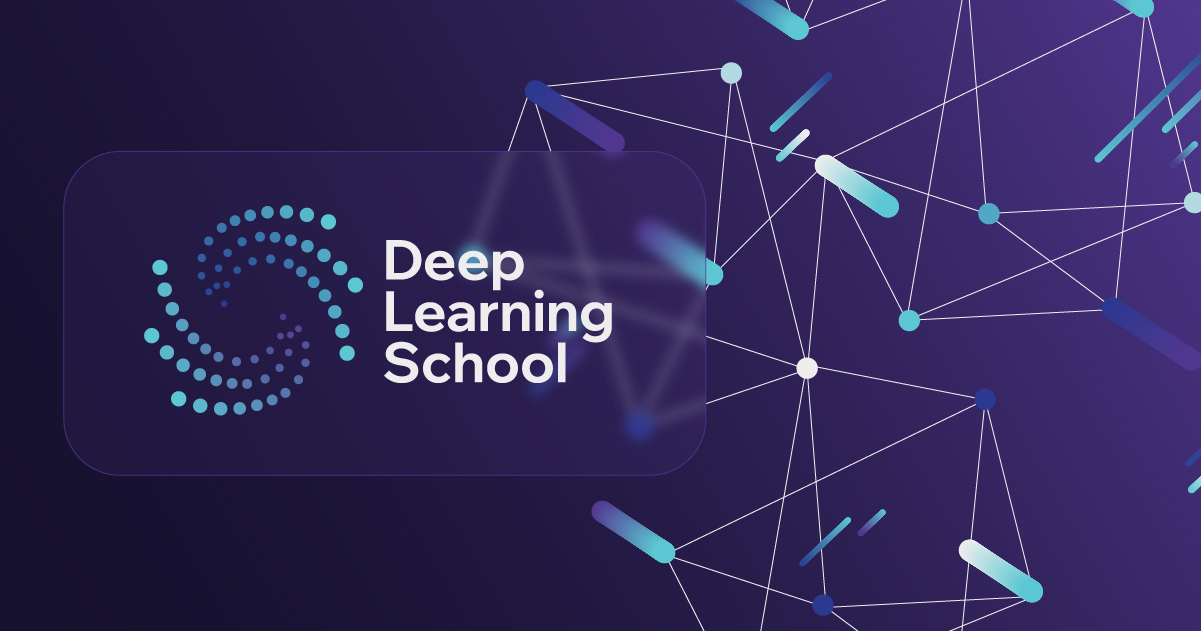

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание по теме "Механизм внимания.</b></h1>


Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Импорт библиотек

In [1]:
import torch
from transformers import AutoModel, AutoConfig
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

In [2]:
import copy
from typing import Union, Dict
from typing import Optional, List
from tqdm import tqdm

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [3]:
class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_labels: int = 2, dropout: float = 0.1):
        super().__init__()

        # Загрузка backbone модели
        if isinstance(base_transformer_model, str):
            self.backbone = AutoModel.from_pretrained(base_transformer_model)
            self.config = AutoConfig.from_pretrained(base_transformer_model)
        else:
            self.backbone = base_transformer_model
            self.config = base_transformer_model.config

        # Дополнительные слои для классификации
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)

    def forward(self, inputs: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        # Пропускаем через backbone
        outputs = self.backbone(**inputs)

        # Берем [CLS] token для классификации
        pooled_output = outputs.last_hidden_state[:, 0, :]

        # Пропускаем через classification head
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        outputs = {
            'logits': logits,
            'hidden_states': outputs.hidden_states,
            'attentions': outputs.attentions
        }
        return outputs

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [4]:
def freeze_backbone_function(model: TransformerClassificationModel, freeze_layers: Optional[List[int]] = None,
                             unfreeze_classifier: bool = True) -> TransformerClassificationModel:
    """
    Расширенная функция заморозки backbone с дополнительными опциями.

    Args:
        model: Экземпляр TransformerClassificationModel
        freeze_layers: Список номеров слоев для заморозки (если None - все слои)
        unfreeze_classifier: Размораживать ли classification head

    Returns:
        TransformerClassificationModel: Модель с замороженными слоями
    """

    if freeze_layers is None:
        # Замораживаем весь backbone
        for param in model.backbone.parameters():
            param.requires_grad = False
    else:
        # Выборочная заморозка определенных слоев
        for layer_idx, layer in enumerate(model.backbone.encoder.layer):
            if layer_idx in freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False

    # Управление заморозкой classification head
    if unfreeze_classifier:
        for param in model.classifier.parameters():
            param.requires_grad = True

        # Размораживаем другие дополнительные слои
        if hasattr(model, 'dropout'):
            for param in model.dropout.parameters():
                param.requires_grad = True

    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [5]:
def train_transformer(transformer_model, freeze_backbone=True, train_loader=None, val_loader=None,
                      num_epochs=3, learning_rate=2e-5, warmup_steps=0):
    """
    Функция для дообучения TransformerClassificationModel

    Args:
        transformer_model: Исходная модель для дообучения
        freeze_backbone: Замораживать ли backbone
        train_loader: DataLoader для тренировочных данных
        val_loader: DataLoader для валидационных данных
        num_epochs: Количество эпох
        learning_rate: Скорость обучения
        warmup_steps: Количество шагов для warmup

    Returns:
        TransformerClassificationModel: Дообученная модель
    """

    # Создаем глубокую копию модели для безопасного изменения
    model = copy.deepcopy(transformer_model)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Замораживаем backbone если необходимо
    if freeze_backbone:
        for param in model.backbone.parameters():
            param.requires_grad = False
        print("Backbone заморожен. Обучается только classification head.")
    else:
        print("Backbone разморожен. Обучается вся модель.")

    # Настраиваем оптимизатор - только для параметров, которые требуют градиентов
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate)

    # Функция потерь
    criterion = nn.CrossEntropyLoss()

    # Создаем фиктивные данные если не переданы
    if train_loader is None:
        print("Внимание: train_loader не передан, используется фиктивный DataLoader")

        # Создаем фиктивные данные для демонстрации
        class DummyDataset(torch.utils.data.Dataset):
            def __len__(self): return 100

            def __getitem__(self, idx):
                return {
                    'input_ids': torch.randint(0, 1000, (128,)),
                    'attention_mask': torch.ones(128),
                    'labels': torch.randint(0, model.classifier.out_features, (1,)).item()
                }

        train_loader = DataLoader(DummyDataset(), batch_size=8)
        val_loader = DataLoader(DummyDataset(), batch_size=8)

    # Настраиваем планировщик обучения
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Цикл обучения
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}')

        for batch in progress_bar:
            # Переносим данные на устройство
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            logits = outputs['logits']

            # Вычисление потерь
            loss = criterion(logits, labels)

            # Backward pass
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Валидация после каждой эпохи
        if val_loader is not None:
            val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
            print(f'Epoch {epoch + 1}: Train Loss: {total_loss / len(train_loader):.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
        else:
            print(f'Epoch {epoch + 1}: Train Loss: {total_loss / len(train_loader):.4f}')

    print("Дообучение завершено!")
    return model

def evaluate_model(model, val_loader, criterion, device):
    """Функция для оценки модели на валидационных данных"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(device)

            outputs = model(inputs)
            logits = outputs['logits']

            loss = criterion(logits, labels)
            total_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    model.train()
    return total_loss / len(val_loader), correct / total

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [6]:
#!pip install hf_xet

In [7]:
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
import torch

#### Датасет и подготовка данных

In [8]:
#!pip install openpyxl

In [9]:
df=pd.read_excel('data_problems.xlsx')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5273 entries, 0 to 5272
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5273 non-null   int64 
 1   Задача      5273 non-null   object
 2   Тема        5273 non-null   object
dtypes: int64(1), object(2)
memory usage: 123.7+ KB


In [11]:
df.head()

,Unnamed: 0,Задача,Тема
0,0,Между девятью планетами Солнечной системы введ...,Графы
1,1,"В стране Цифра есть 9 городов с названиями 1, ...",Графы
2,2,"В государстве 100 городов, и из каждого из них...",Графы
3,3,"В классе 30 человек. Может ли быть так, что 9 ...",Графы
4,4,В городе Маленьком 15 телефонов. Можно ли их с...,Графы


In [12]:
# Кастомный датасет для наших данных
class ProblemsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Токенизация текста
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [13]:
# Загрузка и подготовка данных
def prepare_data(file_path="data_problems.xlsx"):
    # Загружаем данные
    # df = pd.read_csv(file_path, sep=';')
    df=pd.read_excel(file_path)

    # Преобразуем topics в числовые метки
    topics = df['Тема'].unique()
    topic_to_id = {topic: i for i, topic in enumerate(topics)}
    id_to_topic = {i: topic for topic, i in topic_to_id.items()}

    print("Темы в датасете:")
    for topic, topic_id in topic_to_id.items():
        print(f"  {topic}: {topic_id}")

    # Создаем тексты и метки
    texts = df['Задача'].tolist()
    labels = [topic_to_id[topic] for topic in df['Тема']]

    # Статистика
    print(f"\nСтатистика датасета:")
    print(f"Всего примеров: {len(df)}")
    print(f"Распределение по темам:")
    for topic, topic_id in topic_to_id.items():
        count = sum(1 for label in labels if label == topic_id)
        print(f"  {topic}: {count} примеров")

    return texts, labels, topic_to_id, id_to_topic

#### Загрузка данных

In [14]:
# Проверка функции дообучения на реальном датасете
print("Загружаем и подготавливаем данные...")
texts, labels, topic_to_id, id_to_topic = prepare_data("data_problems.xlsx")

# Инициализируем токенизатор для rubert-tiny2
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

# Создаем датасет и разделяем на train/val
dataset = ProblemsDataset(texts, labels, tokenizer)

# Разделяем данные на тренировочные и валидационные (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"\nРазмеры датасетов:")
print(f"Тренировочный: {len(train_dataset)} примеров")
print(f"Валидационный: {len(val_dataset)} примеров")

Загружаем и подготавливаем данные...
Темы в датасете:
  Графы: 0
  Геометрия: 1
  Многочлен: 2
  Комбинаторика: 3
  Теория чисел: 4
  Инвариант: 5
  Дирихле: 6

Статистика датасета:
Всего примеров: 5273
Распределение по темам:
  Графы: 384 примеров
  Геометрия: 371 примеров
  Многочлен: 426 примеров
  Комбинаторика: 1020 примеров
  Теория чисел: 2396 примеров
  Инвариант: 235 примеров
  Дирихле: 441 примеров


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Размеры датасетов:
Тренировочный: 4218 примеров
Валидационный: 1055 примеров


#### Дообучение с замороженным backbone

In [15]:
print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ С ЗАМОРОЖЕННЫМ BACKBONE")
print("=" * 60)
# Первый способ: дообучение с замороженным backbone
rubert_tiny_transformer_model_1 = TransformerClassificationModel(
    "cointegrated/rubert-tiny2",
    num_labels=len(topic_to_id)
)

rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model_1,
    freeze_backbone=True,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5,
    learning_rate=2e-4,  # Больший LR для classification head
    warmup_steps=20
)


ДООБУЧЕНИЕ С ЗАМОРОЖЕННЫМ BACKBONE


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Backbone заморожен. Обучается только classification head.


Epoch 1/5: 100%|██████████| 528/528 [00:16<00:00, 32.36it/s, loss=0.6035]


...

Epoch 3: Train Loss: 1.2177, Val Loss: 1.1764, Val Acc: 0.5678


Epoch 4/5: 100%|██████████| 528/528 [00:06<00:00, 85.37it/s, loss=1.6388]


Epoch 4: Train Loss: 1.1768, Val Loss: 1.1584, Val Acc: 0.5697


Epoch 5/5: 100%|██████████| 528/528 [00:05<00:00, 97.21it/s, loss=0.8714]


Epoch 5: Train Loss: 1.1624, Val Loss: 1.1529, Val Acc: 0.5706
Дообучение завершено!


In [17]:
torch.device

torch.device

#### Дообучение с размороженным backbone

In [18]:
print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ С РАЗМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

# Второй способ: дообучение с размороженным backbone
rubert_tiny_transformer_model_2 = TransformerClassificationModel(
    "cointegrated/rubert-tiny2",
    num_labels=len(topic_to_id)
)

rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model_2,
    freeze_backbone=False,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5,
    learning_rate=2e-5,  # Меньший LR для всего backbone
    warmup_steps=20
)


ДООБУЧЕНИЕ С РАЗМОРОЖЕННЫМ BACKBONE
Backbone разморожен. Обучается вся модель.


Epoch 1/5: 100%|██████████| 528/528 [00:14<00:00, 36.80it/s, loss=2.6333]


Epoch 1: Train Loss: 1.3231, Val Loss: 1.0979, Val Acc: 0.6009


Epoch 2/5: 100%|██████████| 528/528 [00:15<00:00, 34.87it/s, loss=0.1696]


Epoch 2: Train Loss: 1.0242, Val Loss: 1.0261, Val Acc: 0.6199


...

Epoch 3: Train Loss: 0.9122, Val Loss: 0.9811, Val Acc: 0.6114


Epoch 4/5: 100%|██████████| 528/528 [00:14<00:00, 37.43it/s, loss=1.6450]


Epoch 4: Train Loss: 0.8510, Val Loss: 0.9748, Val Acc: 0.6104


Epoch 5/5: 100%|██████████| 528/528 [00:14<00:00, 36.68it/s, loss=0.3096]


Epoch 5: Train Loss: 0.8119, Val Loss: 0.9678, Val Acc: 0.6076
Дообучение завершено!


#### Оценка точности моделей

In [25]:
def evaluate_final_model(model, val_loader, id_to_topic, device='gpu'):
    device = torch.device('cuda' if device == 'gpu' and torch.cuda.is_available() else 'cpu')
    print(f"Используется устройство: {device}")

    model.to(device)
    model.eval()

    correct = 0
    total = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            # Создаем inputs словарь без labels и перемещаем на устройство
            inputs = {}
            for k, v in batch.items():
                if k != 'labels':
                    inputs[k] = v.to(device)
            labels = batch['labels'].to(device)

            # Вызываем модель с inputs
            outputs = model(inputs)

            # Получаем logits
            logits = outputs['logits'] if isinstance(outputs, dict) else outputs
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())

    accuracy = correct / total
    print(f"Точность на валидации: {accuracy:.4f}")

    # ... остальной код вывода
    return accuracy

In [26]:
print("\n" + "=" * 60)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ")
print("=" * 60)


print("Модель с замороженным backbone:")
frozen_accuracy = evaluate_final_model(
    rubert_tiny_finetuned_with_freezed_backbone,
    val_loader,
    id_to_topic
)


ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ
Модель с замороженным backbone:
Используется устройство: cuda
Точность на валидации: 0.5706


In [27]:

print("\nМодель с размороженным backbone:")
full_accuracy = evaluate_final_model(
    rubert_tiny_full_finetuned,
    val_loader,
    id_to_topic
)


Модель с размороженным backbone:
Используется устройство: cuda
Точность на валидации: 0.6076


In [29]:

print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"Точность с замороженным backbone: {frozen_accuracy:.4f}")
print(f"Точность с размороженным backbone: {full_accuracy:.4f}")




СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Точность с замороженным backbone: 0.5706
Точность с размороженным backbone: 0.6076


#### Проверка на конкретных примерах

In [30]:
# Тестирование на нескольких примерах
print("\n" + "=" * 60)
print("ТЕСТИРОВАНИЕ НА КОНКРЕТНЫХ ПРИМЕРАХ")
print("=" * 60)

# Берем несколько примеров из валидации
test_examples = []
for i in range(min(3, len(val_dataset))):
    example = val_dataset[i]
    text = texts[train_size + i]  # Т.к. мы сделали split
    true_topic_id = labels[train_size + i]
    true_topic = id_to_topic[true_topic_id]
    test_examples.append((text, true_topic))

rubert_tiny_finetuned_with_freezed_backbone.eval()
rubert_tiny_full_finetuned.eval()

for i, (text, true_topic) in enumerate(test_examples):
    print(f"\nПример {i + 1}:")
    print(f"Текст: {text[:100]}...")
    print(f"Истинная тема: {true_topic}")

    # Токенизация
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    with torch.no_grad():
        # Предсказание первой модели
        outputs1 = rubert_tiny_finetuned_with_freezed_backbone(encoding)
        logits1 = outputs1['logits']
        probs1 = torch.softmax(logits1, dim=1)
        pred1_id = torch.argmax(probs1, dim=1).item()
        pred1_topic = id_to_topic[pred1_id]
        pred1_conf = probs1[0][pred1_id].item()

        # Предсказание второй модели
        outputs2 = rubert_tiny_full_finetuned(encoding)
        logits2 = outputs2['logits']
        probs2 = torch.softmax(logits2, dim=1)
        pred2_id = torch.argmax(probs2, dim=1).item()
        pred2_topic = id_to_topic[pred2_id]
        pred2_conf = probs2[0][pred2_id].item()

    print(f"Модель с замороженным backbone: {pred1_topic} (уверенность: {pred1_conf:.4f})")
    print(f"Модель с размороженным backbone: {pred2_topic} (уверенность: {pred2_conf:.4f})")
    print(f"Совпадение с истиной: {pred1_topic == true_topic}/{pred2_topic == true_topic}")

print("\n✅ Тестирование завершено!")


ТЕСТИРОВАНИЕ НА КОНКРЕТНЫХ ПРИМЕРАХ

Пример 1:
Текст: Найдите сумму всех правильных несократимых дробей со знаменателем n.
...
Истинная тема: Теория чисел


RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)

#### Оценка точности модели

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# Функция для получения предсказаний модели
def get_predictions(model, data_loader, id_to_topic, device='auto'):
    """
    Получает предсказания модели с поддержкой GPU

    Args:
        model: модель для инференса
        data_loader: DataLoader с данными
        id_to_topic: словарь для преобразования ID в названия тем
        device: 'auto', 'gpu', 'cpu' или конкретное устройство
    """
    # Определение устройства
    if device == 'auto' or device == 'gpu':
        if torch.cuda.is_available():
            device = torch.device('cuda')
            print("✅ Используется GPU для ускорения вычислений")
        else:
            device = torch.device('cpu')
            if device == 'gpu':
                print("⚠️ GPU недоступен, используется CPU")
            else:
                print("ℹ️ Используется CPU")
    else:
        device = torch.device(device)
        print(f"ℹ️ Используется устройство: {device}")

    # Перемещаем модель на выбранное устройство
    model.to(device)
    model.eval()

    all_predictions = []
    all_true_labels = []
    all_probabilities = []

    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            # Перемещаем все тензоры батча на устройство
            inputs = {}
            for k, v in batch.items():
                if k != 'labels':
                    inputs[k] = v.to(device)

            labels = batch['labels'].to(device)

            # Получаем предсказания
            outputs = model(inputs)

            # Универсальное получение logits
            if isinstance(outputs, dict) and 'logits' in outputs:
                logits = outputs['logits']
            elif hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs

            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=1)

            # Сохраняем результаты (перемещаем на CPU)
            all_predictions.extend(predictions.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())
            all_probabilities.extend(probabilities.cpu().tolist())

            # Прогресс для больших датасетов
            if (i + 1) % 10 == 0:
                print(f"Обработано батчей: {i + 1}")

    # Преобразуем ID в названия тем
    pred_topics = [id_to_topic[pred] for pred in all_predictions]
    true_topics = [id_to_topic[true] for true in all_true_labels]

    print(f"✅ Получено {len(all_predictions)} предсказаний")
    return true_topics, pred_topics, all_probabilities

In [36]:
# Создаем полный отчет по классификации
def create_classification_report(model, data_loader, id_to_topic, model_name="Model"):
    print(f"\n{'=' * 80}")
    print(f"ОТЧЕТ ПО КЛАССИФИКАЦИИ: {model_name}")
    print(f"{'=' * 80}")

    # Получаем предсказания
    true_labels, pred_labels, probabilities = get_predictions(model, data_loader, id_to_topic)

    # 1. Classification Report от sklearn
    print("\n1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:")
    print("-" * 50)
    report = classification_report(true_labels, pred_labels, output_dict=False)
    print(report)

    # 2. Accuracy
    accuracy = accuracy_score(true_labels, pred_labels)
    print(f"\n2. ОБЩАЯ ТОЧНОСТЬ: {accuracy:.4f}")

    # 3. Confusion Matrix
    print(f"\n3. МАТРИЦА ОШИБОК:")
    cm = confusion_matrix(true_labels, pred_labels, labels=list(id_to_topic.values()))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=id_to_topic.values(),
                yticklabels=id_to_topic.values())
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.tight_layout()
    plt.show()

    # 4. Статистика по классам
    print(f"\n4. СТАТИСТИКА ПО КЛАССАМ:")
    print("-" * 40)
    unique_true = np.unique(true_labels, return_counts=True)
    unique_pred = np.unique(pred_labels, return_counts=True)

    print("Распределение истинных меток:")
    for topic, count in zip(unique_true[0], unique_true[1]):
        print(f"  {topic}: {count} примеров")

    print("\nРаспределение предсказанных меток:")
    for topic, count in zip(unique_pred[0], unique_pred[1]):
        print(f"  {topic}: {count} примеров")

    # 5. Детальный анализ ошибок
    print(f"\n5. АНАЛИЗ ОШИБОК:")
    print("-" * 40)
    errors = []
    for i, (true, pred) in enumerate(zip(true_labels, pred_labels)):
        if true != pred:
            errors.append({
                'index': i,
                'true': true,
                'predicted': pred,
                'confidence': max(probabilities[i])
            })

    if errors:
        print(f"Всего ошибок: {len(errors)}")
        print("\nПримеры ошибок (первые 5):")
        for error in errors[:5]:
            print(f"  Пример {error['index']}: {error['true']} → {error['predicted']} "
                  f"(уверенность: {error['confidence']:.4f})")
    else:
        print("Ошибок не обнаружено!")

    # 6. Метрики в виде DataFrame для удобства
    report_dict = classification_report(true_labels, pred_labels, output_dict=True)
    metrics_df = pd.DataFrame(report_dict).transpose()

    return {
        'true_labels': true_labels,
        'pred_labels': pred_labels,
        'probabilities': probabilities,
        'accuracy': accuracy,
        'classification_report': report_dict,
        'confusion_matrix': cm,
        'metrics_df': metrics_df
    }


Подготовка данных для rubert-tiny2...
Темы в датасете:
  Графы: 0
  Геометрия: 1
  Многочлен: 2
  Комбинаторика: 3
  Теория чисел: 4
  Инвариант: 5
  Дирихле: 6

Статистика датасета:
Всего примеров: 5273
Распределение по темам:
  Графы: 384 примеров
  Геометрия: 371 примеров
  Многочлен: 426 примеров
  Комбинаторика: 1020 примеров
  Теория чисел: 2396 примеров
  Инвариант: 235 примеров
  Дирихле: 441 примеров

Загрузка моделей rubert-tiny2...
Создание отчетов...

ОТЧЕТ ПО КЛАССИФИКАЦИИ: RuBert-Tiny2 (замороженный backbone)
✅ Используется GPU для ускорения вычислений
Обработано батчей: 10
Обработано батчей: 20
Обработано батчей: 30
Обработано батчей: 40
Обработано батчей: 50
Обработано батчей: 60
Обработано батчей: 70
Обработано батчей: 80
Обработано батчей: 90
Обработано батчей: 100
Обработано батчей: 110
Обработано батчей: 120
Обработано батчей: 130
✅ Получено 1055 предсказаний

1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:
--------------------------------------------------
               pre

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


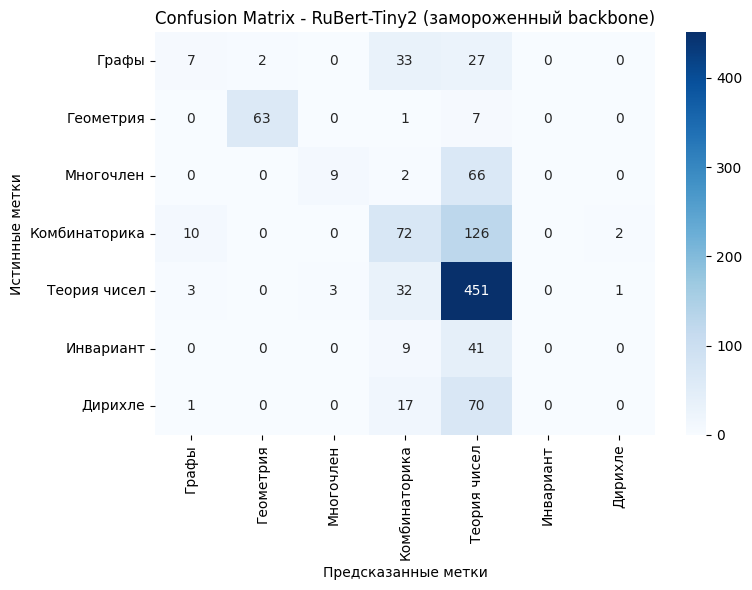


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 65 примеров
  Графы: 21 примеров
  Дирихле: 3 примеров
  Комбинаторика: 166 примеров
  Многочлен: 12 примеров
  Теория чисел: 788 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 453

Примеры ошибок (первые 5):
  Пример 0: Дирихле → Теория чисел (уверенность: 0.4105)
  Пример 2: Дирихле → Теория чисел (уверенность: 0.3244)
  Пример 3: Дирихле → Теория чисел (уверенность: 0.7143)
  Пример 8: Дирихле → Теория чисел (уверенность: 0.3059)
  Пример 10: Комбинаторика → Графы (уверенность: 0.4546)

ОТЧЕТ ПО КЛАССИФИКАЦИИ: RuBert-Tiny2 (размороженный backbone)
✅ Используется GPU для ускорения вычислений
Обработано батчей: 10


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Обработано батчей: 20
Обработано батчей: 30
Обработано батчей: 40
Обработано батчей: 50
Обработано батчей: 60
Обработано батчей: 70
Обработано батчей: 80
Обработано батчей: 90
Обработано батчей: 100
Обработано батчей: 110
Обработано батчей: 120
Обработано батчей: 130
✅ Получено 1055 предсказаний

1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:
--------------------------------------------------
               precision    recall  f1-score   support

    Геометрия       0.00      0.00      0.00        71
        Графы       0.09      0.10      0.10        69
      Дирихле       0.07      0.58      0.13        88
    Инвариант       0.03      0.02      0.02        50
Комбинаторика       0.25      0.12      0.17       210
    Многочлен       0.02      0.04      0.03        77
 Теория чисел       0.29      0.00      0.01       490

     accuracy                           0.09      1055
    macro avg       0.11      0.12      0.06      1055
 weighted avg       0.20      0.09      0.06      1055


2. О

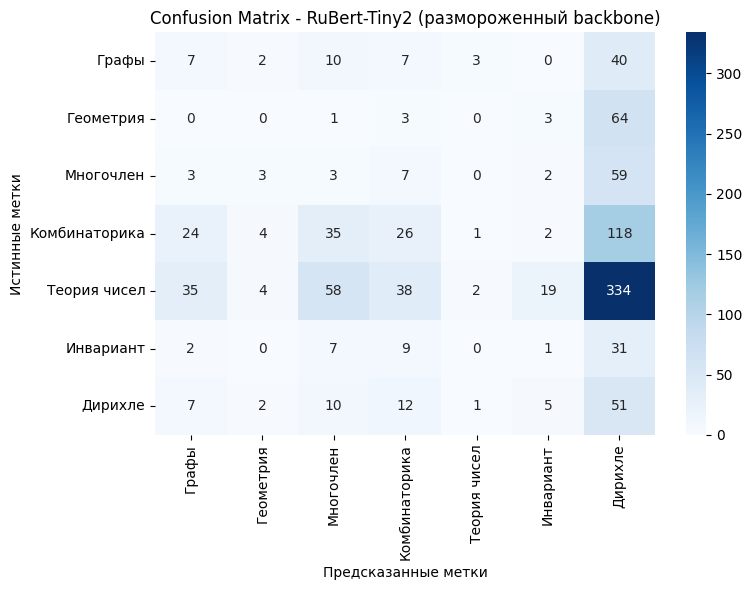


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 15 примеров
  Графы: 78 примеров
  Дирихле: 697 примеров
  Инвариант: 32 примеров
  Комбинаторика: 102 примеров
  Многочлен: 124 примеров
  Теория чисел: 7 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 965

Примеры ошибок (первые 5):
  Пример 1: Теория чисел → Дирихле (уверенность: 0.2185)
  Пример 4: Теория чисел → Дирихле (уверенность: 0.2788)
  Пример 5: Теория чисел → Дирихле (уверенность: 0.2303)
  Пример 6: Теория чисел → Дирихле (уверенность: 0.2646)
  Пример 7: Геометрия → Дирихле (уверенность: 0.3011)

СРАВНИТЕЛЬНЫЙ ОТЧЕТ

ОТЧЕТ ПО КЛАССИФИКАЦИИ: Замороженный backbone
✅ Используется GPU для ускорения вычислений
Обработано

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


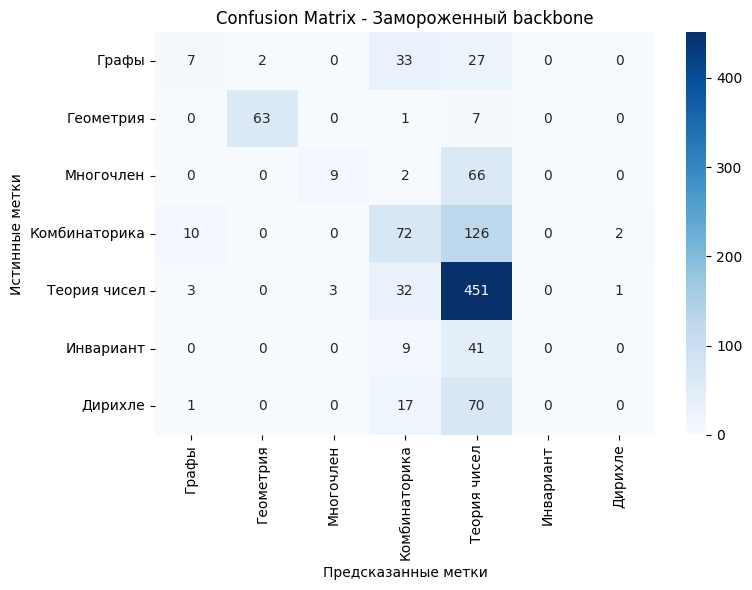


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 65 примеров
  Графы: 21 примеров
  Дирихле: 3 примеров
  Комбинаторика: 166 примеров
  Многочлен: 12 примеров
  Теория чисел: 788 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 453

Примеры ошибок (первые 5):
  Пример 0: Дирихле → Теория чисел (уверенность: 0.4105)
  Пример 2: Дирихле → Теория чисел (уверенность: 0.3244)
  Пример 3: Дирихле → Теория чисел (уверенность: 0.7143)
  Пример 8: Дирихле → Теория чисел (уверенность: 0.3059)
  Пример 10: Комбинаторика → Графы (уверенность: 0.4546)

ОТЧЕТ ПО КЛАССИФИКАЦИИ: Размороженный backbone
✅ Используется GPU для ускорения вычислений
Обработано батчей: 10
Обработано батчей: 20


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Обработано батчей: 30
Обработано батчей: 40
Обработано батчей: 50
Обработано батчей: 60
Обработано батчей: 70
Обработано батчей: 80
Обработано батчей: 90
Обработано батчей: 100
Обработано батчей: 110
Обработано батчей: 120
Обработано батчей: 130
✅ Получено 1055 предсказаний

1. ДЕТАЛИЗИРОВАННЫЙ ОТЧЕТ ПО КЛАССАМ:
--------------------------------------------------
               precision    recall  f1-score   support

    Геометрия       0.00      0.00      0.00        71
        Графы       0.09      0.10      0.10        69
      Дирихле       0.07      0.58      0.13        88
    Инвариант       0.03      0.02      0.02        50
Комбинаторика       0.25      0.12      0.17       210
    Многочлен       0.02      0.04      0.03        77
 Теория чисел       0.29      0.00      0.01       490

     accuracy                           0.09      1055
    macro avg       0.11      0.12      0.06      1055
 weighted avg       0.20      0.09      0.06      1055


2. ОБЩАЯ ТОЧНОСТЬ: 0.0853


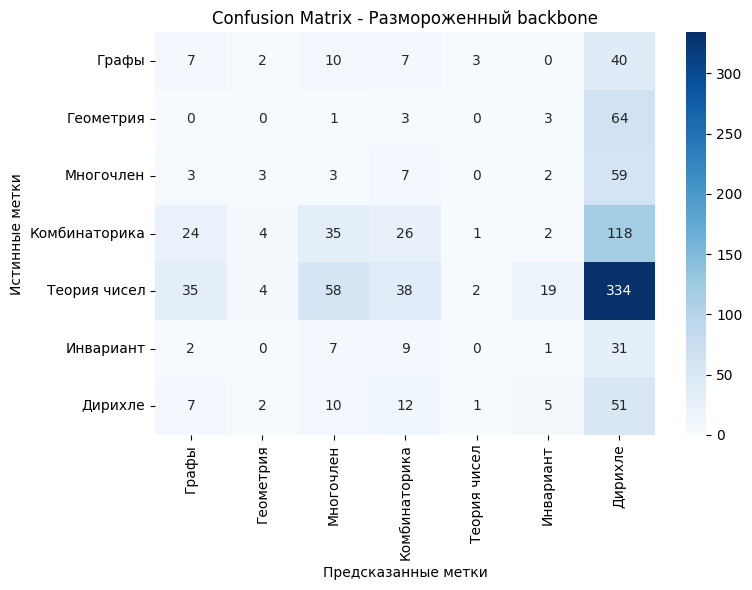


4. СТАТИСТИКА ПО КЛАССАМ:
----------------------------------------
Распределение истинных меток:
  Геометрия: 71 примеров
  Графы: 69 примеров
  Дирихле: 88 примеров
  Инвариант: 50 примеров
  Комбинаторика: 210 примеров
  Многочлен: 77 примеров
  Теория чисел: 490 примеров

Распределение предсказанных меток:
  Геометрия: 15 примеров
  Графы: 78 примеров
  Дирихле: 697 примеров
  Инвариант: 32 примеров
  Комбинаторика: 102 примеров
  Многочлен: 124 примеров
  Теория чисел: 7 примеров

5. АНАЛИЗ ОШИБОК:
----------------------------------------
Всего ошибок: 965

Примеры ошибок (первые 5):
  Пример 1: Теория чисел → Дирихле (уверенность: 0.2185)
  Пример 4: Теория чисел → Дирихле (уверенность: 0.2788)
  Пример 5: Теория чисел → Дирихле (уверенность: 0.2303)
  Пример 6: Теория чисел → Дирихле (уверенность: 0.2646)
  Пример 7: Геометрия → Дирихле (уверенность: 0.3011)

6. СРАВНЕНИЕ МОДЕЛЕЙ:
--------------------------------------------------
Метрика              Замороженный backbone     Р

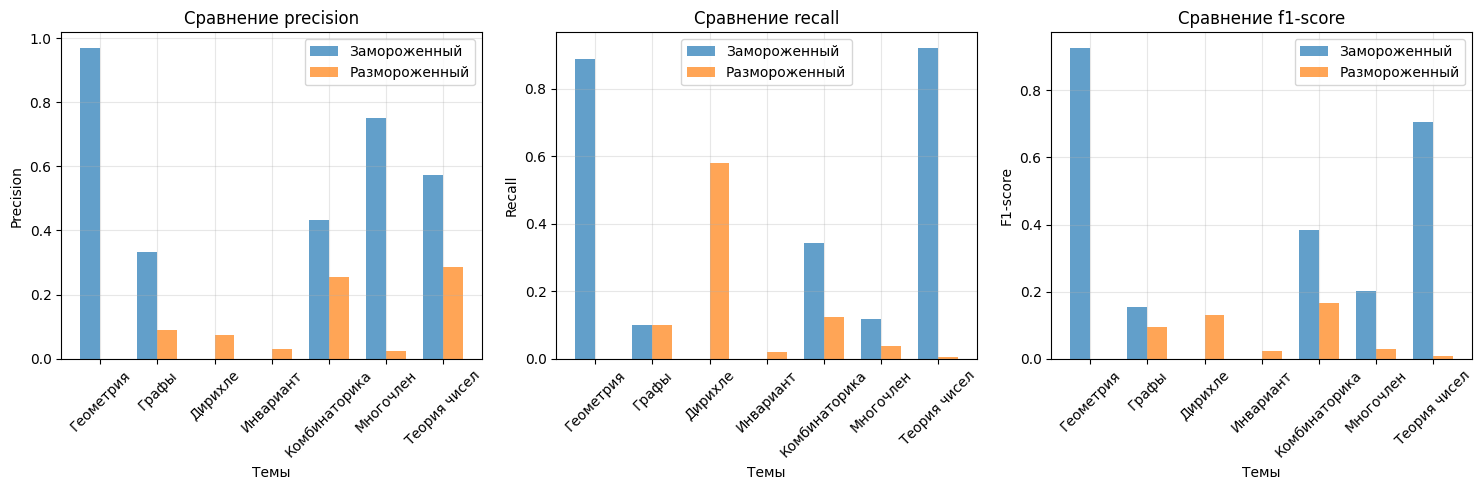

In [37]:
# Сравнительный отчет двух моделей
def create_comparison_report(model1, model2, data_loader, id_to_topic,
                             model1_name="Модель 1", model2_name="Модель 2"):
    print(f"\n{'=' * 80}")
    print(f"СРАВНИТЕЛЬНЫЙ ОТЧЕТ")
    print(f"{'=' * 80}")

    # Получаем результаты для обеих моделей
    results1 = create_classification_report(model1, data_loader, id_to_topic, model1_name)
    results2 = create_classification_report(model2, data_loader, id_to_topic, model2_name)

    print(f"\n6. СРАВНЕНИЕ МОДЕЛЕЙ:")
    print("-" * 50)
    print(f"{'Метрика':<20} {model1_name:<25} {model2_name:<25}")
    print("-" * 70)
    print(f"{'Accuracy':<20} {results1['accuracy']:<25.4f} {results2['accuracy']:<25.4f}")

    # Сравнение precision, recall, f1 для каждого класса
    for topic in id_to_topic.values():
        if topic in results1['classification_report']:
            prec1 = results1['classification_report'][topic]['precision']
            prec2 = results2['classification_report'][topic]['precision']
            rec1 = results1['classification_report'][topic]['recall']
            rec2 = results2['classification_report'][topic]['recall']
            f11 = results1['classification_report'][topic]['f1-score']
            f12 = results2['classification_report'][topic]['f1-score']

            print(f"{topic + ' Precision':<20} {prec1:<25.4f} {prec2:<25.4f}")
            print(f"{topic + ' Recall':<20} {rec1:<25.4f} {rec2:<25.4f}")
            print(f"{topic + ' F1-score':<20} {f11:<25.4f} {f12:<25.4f}")
            print("-" * 70)

    return results1, results2


# Основная функция для создания отчета по rubert-tiny2
def create_rubert_tiny_report():
    # Загружаем данные (аналогично предыдущему коду)
    print("Подготовка данных для rubert-tiny2...")
    texts, labels, topic_to_id, id_to_topic = prepare_data("data_problems.xlsx")

    # Инициализируем токенизатор
    tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

    # Создаем датасет
    dataset = ProblemsDataset(texts, labels, tokenizer)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    # Загружаем дообученные модели (предполагая, что они уже сохранены)
    print("\nЗагрузка моделей rubert-tiny2...")

    # Модель с замороженным backbone
    # rubert_tiny_frozen = TransformerClassificationModel(
    #     "cointegrated/rubert-tiny2",
    #     num_labels=len(topic_to_id)
    # )
    #
    rubert_tiny_frozen=rubert_tiny_finetuned_with_freezed_backbone

    # Модель с размороженным backbone
    rubert_tiny_full = TransformerClassificationModel(
        "cointegrated/rubert-tiny2",
        num_labels=len(topic_to_id)
    )
    rubert_tiny_full = rubert_tiny_full
    # Здесь должны быть загружены веса дообученных моделей
    # rubert_tiny_frozen.load_state_dict(torch.load('rubert_tiny_frozen.pth'))
    # rubert_tiny_full.load_state_dict(torch.load('rubert_tiny_full.pth'))

    print("Создание отчетов...")

    # Создаем индивидуальные отчеты
    frozen_results = create_classification_report(
        rubert_tiny_frozen, val_loader, id_to_topic,
        "RuBert-Tiny2 (замороженный backbone)"
    )

    full_results = create_classification_report(
        rubert_tiny_full, val_loader, id_to_topic,
        "RuBert-Tiny2 (размороженный backbone)"
    )

    # Создаем сравнительный отчет
    comparison_results = create_comparison_report(
        rubert_tiny_frozen, rubert_tiny_full, val_loader, id_to_topic,
        "Замороженный backbone", "Размороженный backbone"
    )

    # Сохраняем результаты в файлы
    frozen_results['metrics_df'].to_csv('rubert_tiny_frozen_metrics.csv')
    full_results['metrics_df'].to_csv('rubert_tiny_full_metrics.csv')

    print("\n✅ Отчеты сохранены в файлы:")
    print("   - rubert_tiny_frozen_metrics.csv")
    print("   - rubert_tiny_full_metrics.csv")

    return frozen_results, full_results


# Дополнительная функция для визуализации
def plot_comparison_metrics(frozen_results, full_results):
    """Визуализация сравнения метрик двух моделей"""

    metrics = ['precision', 'recall', 'f1-score']
    topics = list(frozen_results['classification_report'].keys())[:-3]  # Исключаем средние

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, metric in enumerate(metrics):
        frozen_scores = [frozen_results['classification_report'][topic][metric] for topic in topics]
        full_scores = [full_results['classification_report'][topic][metric] for topic in topics]

        x = np.arange(len(topics))
        width = 0.35

        axes[idx].bar(x - width / 2, frozen_scores, width, label='Замороженный', alpha=0.7)
        axes[idx].bar(x + width / 2, full_scores, width, label='Размороженный', alpha=0.7)

        axes[idx].set_xlabel('Темы')
        axes[idx].set_ylabel(metric.capitalize())
        axes[idx].set_title(f'Сравнение {metric}')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(topics, rotation=45)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Запуск создания отчетов
if __name__ == "__main__":
    frozen_results, full_results = create_rubert_tiny_report()
    plot_comparison_metrics(frozen_results, full_results)

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [41]:
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
import torch


# Кастомный датасет для наших данных
class ProblemsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Токенизация текста
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


# Загрузка и подготовка данных
def prepare_data(file_path="data_problems_translated.csv"):
    # Загружаем данные
    df = pd.read_csv(file_path, sep=';')

    # Преобразуем topics в числовые метки
    topics = df['topic'].unique()
    topic_to_id = {topic: i for i, topic in enumerate(topics)}
    id_to_topic = {i: topic for topic, i in topic_to_id.items()}

    print("Темы в датасете:")
    for topic, topic_id in topic_to_id.items():
        print(f"  {topic}: {topic_id}")

    # Создаем тексты и метки
    texts = df['problem_text'].tolist()
    labels = [topic_to_id[topic] for topic in df['topic']]

    # Статистика
    print(f"\nСтатистика датасета:")
    print(f"Всего примеров: {len(df)}")
    print(f"Распределение по темам:")
    for topic, topic_id in topic_to_id.items():
        count = sum(1 for label in labels if label == topic_id)
        print(f"  {topic}: {count} примеров")

    return texts, labels, topic_to_id, id_to_topic


# Определяем устройство (GPU или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Проверка функции дообучения на реальном датасете с MathBert
print("Загружаем и подготавливаем данные...")
texts, labels, topic_to_id, id_to_topic = prepare_data("data_problems_translated.csv")

# Инициализируем токенизатор для MathBert
tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBert")

# Создаем датасет и разделяем на train/val
dataset = ProblemsDataset(texts, labels, tokenizer)

# Разделяем данные на тренировочные и валидационные (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"\nРазмеры датасетов:")
print(f"Тренировочный: {len(train_dataset)} примеров")
print(f"Валидационный: {len(val_dataset)} примеров")

print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ MATHBERT С ЗАМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

# Первый способ: дообучение с замороженным backbone
mathbert_model_1 = TransformerClassificationModel(
    "tbs17/MathBert",  # ИЗМЕНЕНИЕ: используем MathBert вместо rubert-tiny2
    num_labels=len(topic_to_id)
).to(device)  # ПЕРЕНОСИМ МОДЕЛЬ НА GPU

mathbert_finetuned_with_freezed_backbone = train_transformer(
    mathbert_model_1,
    freeze_backbone=True,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5,
    learning_rate=2e-4,
    warmup_steps=20,
)

print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ MATHBERT С РАЗМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

# Второй способ: дообучение с размороженным backbone
mathbert_model_2 = TransformerClassificationModel(
    "tbs17/MathBert",  # ИЗМЕНЕНИЕ: используем MathBert вместо rubert-tiny2
    num_labels=len(topic_to_id)
).to(device)  # ПЕРЕНОСИМ МОДЕЛЬ НА GPU

mathbert_full_finetuned = train_transformer(
    mathbert_model_2,
    freeze_backbone=False,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5,
    learning_rate=2e-5,
    warmup_steps=20,
)

print("\n" + "=" * 60)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ")
print("=" * 60)


# Функция для оценки точности
def evaluate_final_model(model, val_loader, id_to_topic, device):
    model.eval()
    model.to(device)  # УБЕДИМСЯ, ЧТО МОДЕЛЬ НА ПРАВИЛЬНОМ УСТРОЙСТВЕ
    correct = 0
    total = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            # ПЕРЕНОСИМ ДАННЫЕ НА УСТРОЙСТВО
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(device)

            outputs = model(inputs)
            logits = outputs['logits']
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())

    accuracy = correct / total

    # Детальная информация по классам
    print(f"Точность на валидации: {accuracy:.4f}")
    print("\nДетали по темам:")
    for topic_id, topic_name in id_to_topic.items():
        topic_correct = sum(1 for pred, true in zip(all_predictions, all_true_labels)
                            if true == topic_id and pred == true)
        topic_total = sum(1 for true in all_true_labels if true == topic_id)
        if topic_total > 0:
            topic_acc = topic_correct / topic_total
            print(f"  {topic_name}: {topic_correct}/{topic_total} ({topic_acc:.4f})")

    return accuracy


print("MathBert с замороженным backbone:")
frozen_accuracy = evaluate_final_model(
    mathbert_finetuned_with_freezed_backbone,
    val_loader,
    id_to_topic,
    device
)

print("\nMathBert с размороженным backbone:")
full_accuracy = evaluate_final_model(
    mathbert_full_finetuned,
    val_loader,
    id_to_topic,
    device
)

print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ MATHBERT")
print("=" * 60)
print(f"Точность с замороженным backbone: {frozen_accuracy:.4f}")
print(f"Точность с размороженным backbone: {full_accuracy:.4f}")

# Тестирование на нескольких примерах
print("\n" + "=" * 60)
print("ТЕСТИРОВАНИЕ НА КОНКРЕТНЫХ ПРИМЕРАХ")
print("=" * 60)

# Берем несколько примеров из валидации
test_examples = []
for i in range(min(3, len(val_dataset))):
    example = val_dataset[i]
    text = texts[train_size + i]
    true_topic_id = labels[train_size + i]
    true_topic = id_to_topic[true_topic_id]
    test_examples.append((text, true_topic))

mathbert_finetuned_with_freezed_backbone.eval()
mathbert_full_finetuned.eval()

for i, (text, true_topic) in enumerate(test_examples):
    print(f"\nПример {i + 1}:")
    print(f"Текст: {text[:100]}...")
    print(f"Истинная тема: {true_topic}")

    # Токенизация
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    # ПЕРЕНОСИМ ДАННЫЕ НА УСТРОЙСТВО
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        # Предсказание первой модели
        outputs1 = mathbert_finetuned_with_freezed_backbone(encoding)
        logits1 = outputs1['logits']
        probs1 = torch.softmax(logits1, dim=1)
        pred1_id = torch.argmax(probs1, dim=1).item()
        pred1_topic = id_to_topic[pred1_id]
        pred1_conf = probs1[0][pred1_id].item()

        # Предсказание второй модели
        outputs2 = mathbert_full_finetuned(encoding)
        logits2 = outputs2['logits']
        probs2 = torch.softmax(logits2, dim=1)
        pred2_id = torch.argmax(probs2, dim=1).item()
        pred2_topic = id_to_topic[pred2_id]
        pred2_conf = probs2[0][pred2_id].item()

    print(f"MathBert с замороженным backbone: {pred1_topic} (уверенность: {pred1_conf:.4f})")
    print(f"MathBert с размороженным backbone: {pred2_topic} (уверенность: {pred2_conf:.4f})")
    print(f"Совпадение с истиной: {pred1_topic == true_topic}/{pred2_topic == true_topic}")

print("\n✅ Тестирование MathBert завершено!")

Используется устройство: cuda
Загружаем и подготавливаем данные...
Темы в датасете:
  number_theory: 0
  polynoms: 1
  combinatorics: 2
  graphs: 3
  geometry: 4
  invariant: 5
  dirichlet: 6

Статистика датасета:
Всего примеров: 5273
Распределение по темам:
  number_theory: 2396 примеров
  polynoms: 426 примеров
  combinatorics: 1020 примеров
  graphs: 384 примеров
  geometry: 371 примеров
  invariant: 235 примеров
  dirichlet: 441 примеров

Размеры датасетов:
Тренировочный: 4218 примеров
Валидационный: 1055 примеров

ДООБУЧЕНИЕ MATHBERT С ЗАМОРОЖЕННЫМ BACKBONE
Backbone заморожен. Обучается только classification head.


Epoch 1/5: 100%|██████████| 528/528 [00:32<00:00, 16.24it/s, loss=1.0022]


Epoch 1: Train Loss: 1.4922, Val Loss: 1.2936, Val Acc: 0.5299


Epoch 2/5: 100%|██████████| 528/528 [00:32<00:00, 16.43it/s, loss=1.2403]


Epoch 2: Train Loss: 1.2674, Val Loss: 1.1960, Val Acc: 0.5526


...

Epoch 3: Train Loss: 0.6174, Val Loss: 1.1179, Val Acc: 0.5678


Epoch 4/5: 100%|██████████| 528/528 [01:45<00:00,  4.98it/s, loss=0.0961]


Epoch 4: Train Loss: 0.4693, Val Loss: 1.2404, Val Acc: 0.5602


Epoch 5/5: 100%|██████████| 528/528 [01:45<00:00,  4.98it/s, loss=0.8410]


Epoch 5: Train Loss: 0.3726, Val Loss: 1.3350, Val Acc: 0.5507
Дообучение завершено!

ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ВАЛИДАЦИИ
MathBert с замороженным backbone:
Точность на валидации: 0.5592

Детали по темам:
  number_theory: 417/483 (0.8634)
  polynoms: 34/75 (0.4533)
  combinatorics: 58/206 (0.2816)
  graphs: 7/84 (0.0833)
  geometry: 73/83 (0.8795)
  invariant: 0/43 (0.0000)
  dirichlet: 1/81 (0.0123)

MathBert с размороженным backbone:
Точность на валидации: 0.5507

Детали по темам:
  number_theory: 365/483 (0.7557)
  polynoms: 46/75 (0.6133)
  combinatorics: 64/206 (0.3107)
  graphs: 5/84 (0.0595)
  geometry: 80/83 (0.9639)
  invariant: 4/43 (0.0930)
  dirichlet: 17/81 (0.2099)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ MATHBERT
Точность с замороженным backbone: 0.5592
Точность с размороженным backbone: 0.5507

ТЕСТИРОВАНИЕ НА КОНКРЕТНЫХ ПРИМЕРАХ

Пример 1:
Текст: Prove the number 192021...7980 divided by 1980....
Истинная тема: number_theory
MathBert с замороженным backbone: number_theory (уверенность: 0

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
def draw_first_layer_attention_maps(attention_head_ids: List, text: str, model: TransformerClassificationModel):
    pass

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [ ]:
### YOUR CODE IS HERE

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

In [ ]:
### YOUR CODE IS HERE